# Day / Night Image Classifier — CNN from Scratch

Binary CNN classifier trained on 749 cityview images (522 day · 227 night).

**Pipeline:** Load → Preprocess → Augment → Train → Evaluate

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.21.0
GPU        : []


In [14]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image settings
IMG_SIZE = 128      # resize to 128×128 px
CHANNELS = 3

# Training hypers
BATCH_SIZE = 32
EPOCHS     = 50

# Paths — notebook lives in CNN/, dataset is a sibling folder
DATASET_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'dataset'))
DAY_DIR     = os.path.join(DATASET_DIR, 'day')
NIGHT_DIR   = os.path.join(DATASET_DIR, 'night')

# Labels: 0 = Night, 1 = Day
CLASS_NAMES = {0: 'Night', 1: 'Day'}

print(f"Dataset : {DATASET_DIR}")
print(f"Day     : {len(os.listdir(DAY_DIR))} images")
print(f"Night   : {len(os.listdir(NIGHT_DIR))} images")

Dataset : c:\Users\meism\Desktop\Bon Voyage\dataset
Day     : 522 images
Night   : 227 images


In [15]:
def load_images(folder, label, size=(IMG_SIZE, IMG_SIZE)):
    """
    Load all images from a folder and return preprocessed arrays + labels.

    Preprocessing steps:
      1. cv2.imread  — handles missing / corrupt files (returns None)
      2. BGR → RGB   — cv2 reads in BGR; models expect RGB
      3. INTER_AREA  — best interpolation quality for downscaling
      4. float32 /255 — normalise pixel values to [0, 1]
    """
    images, labels = [], []
    skipped = 0

    for fname in sorted(os.listdir(folder)):
        fpath = os.path.join(folder, fname)
        img = cv2.imread(fpath)

        if img is None:          # skip corrupt or non-image files
            skipped += 1
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(label)

    if skipped:
        print(f"  Skipped {skipped} unreadable file(s) in {os.path.basename(folder)}/")

    return images, labels

print("load_images() defined.")

load_images() defined.


In [16]:
print("Loading images…")
day_imgs,   day_lbl   = load_images(DAY_DIR,   label=1)
night_imgs, night_lbl = load_images(NIGHT_DIR, label=0)

X = np.array(day_imgs + night_imgs, dtype=np.float32)   # (N, 128, 128, 3)
y = np.array(day_lbl  + night_lbl,  dtype=np.int32)     # (N,)

print(f"\nTotal samples : {len(X)}")
print(f"  Day   (1)   : {int(y.sum())}")
print(f"  Night (0)   : {int((y == 0).sum())}")
print(f"Image shape   : {X.shape[1:]}")
print(f"Pixel range   : [{X.min():.3f}, {X.max():.3f}]")

Loading images…

Total samples : 749
  Day   (1)   : 522
  Night (0)   : 227
Image shape   : (128, 128, 3)
Pixel range   : [0.000, 1.000]


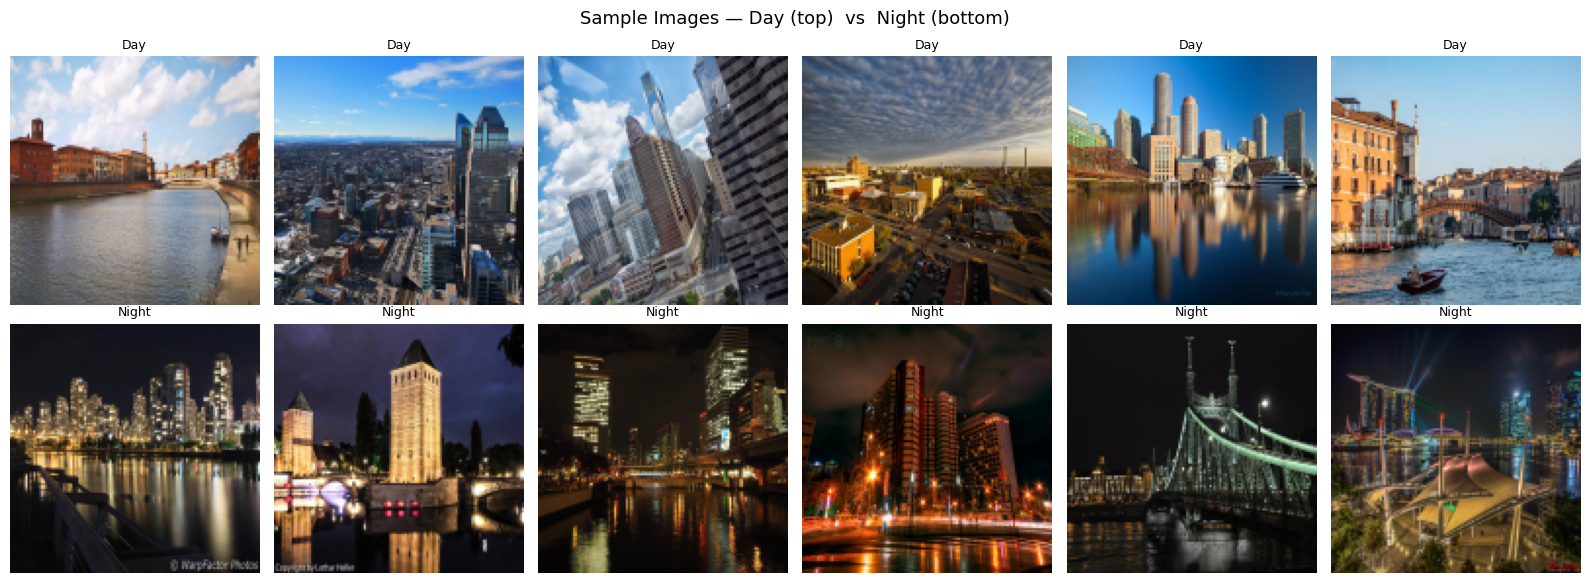

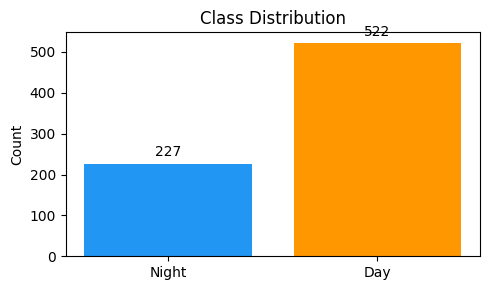

In [17]:
# --- Sample images ---
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample Images — Day (top)  vs  Night (bottom)", fontsize=13)

rng       = np.random.default_rng(SEED)
day_idx   = np.where(y == 1)[0]
night_idx = np.where(y == 0)[0]

for col, i in enumerate(rng.choice(day_idx,   6, replace=False)):
    axes[0, col].imshow(X[i]);  axes[0, col].axis('off');  axes[0, col].set_title("Day",   fontsize=9)

for col, i in enumerate(rng.choice(night_idx, 6, replace=False)):
    axes[1, col].imshow(X[i]);  axes[1, col].axis('off');  axes[1, col].set_title("Night", fontsize=9)

plt.tight_layout();  plt.show()

# --- Class distribution ---
fig, ax = plt.subplots(figsize=(5, 3))
classes, counts = np.unique(y, return_counts=True)
bars = ax.bar([CLASS_NAMES[c] for c in classes], counts, color=['#2196F3', '#FF9800'])
ax.bar_label(bars, padding=3)
ax.set_title("Class Distribution");  ax.set_ylabel("Count")
plt.tight_layout();  plt.show()

In [18]:
# Stratified split: 70 % train · 15 % val · 15 % test
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, stratify=y_tv, random_state=SEED
)

print(f"Train : {X_train.shape}  day={y_train.sum()}, night={(y_train==0).sum()}")
print(f"Val   : {X_val.shape}    day={y_val.sum()}, night={(y_val==0).sum()}")
print(f"Test  : {X_test.shape}   day={y_test.sum()}, night={(y_test==0).sum()}")

# Class weights — let the model compensate for the 522/227 imbalance
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print(f"\nClass weights : {class_weight_dict}")

Train : (523, 128, 128, 3)  day=364, night=159
Val   : (113, 128, 128, 3)    day=79, night=34
Test  : (113, 128, 128, 3)   day=79, night=34

Class weights : {0: np.float64(1.6446540880503144), 1: np.float64(0.7184065934065934)}


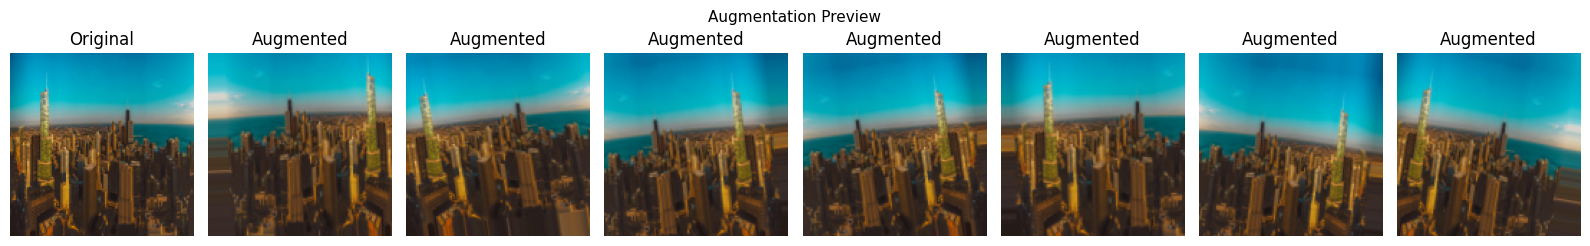

In [19]:
# Augmentation applied ONLY to training images.
# Brightness is intentionally excluded — luminance is a core day/night signal
# and randomising it would corrupt the labels.
aug_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Preview augmented variants of a single training image
sample = X_train[:1]
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
axes[0].imshow(sample[0]);  axes[0].set_title("Original");  axes[0].axis('off')
for ax, batch in zip(axes[1:], aug_gen.flow(sample, batch_size=1)):
    ax.imshow(batch[0]);  ax.set_title("Augmented");  ax.axis('off')
plt.suptitle("Augmentation Preview", fontsize=11)
plt.tight_layout();  plt.show()

In [20]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    inputs = keras.Input(shape=input_shape)

    # Block 1  128 → 64
    x = layers.Conv2D(32,  (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x);  x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x);  x = layers.Dropout(0.1)(x)

    # Block 2  64 → 32
    x = layers.Conv2D(64,  (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x);  x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x);  x = layers.Dropout(0.1)(x)

    # Block 3  32 → 16
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x);  x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x);  x = layers.Dropout(0.2)(x)

    # Block 4  16 → GlobalAvgPool
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x);  x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Classifier head
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x);  x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='DayNightCNN')

model = build_cnn()
model.summary()

Model: "DayNightCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 457,409 (1.74 MB)

 Trainable params: 455,937 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [21]:
model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_daynight_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    aug_gen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=max(1, len(X_train) // BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.8839 - auc: 0.9749 - loss: 0.2408 - val_accuracy: 0.7522 - val_auc: 0.9905 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9688 - auc: 0.9952 - loss: 0.1288 - val_accuracy: 0.7522 - val_auc: 0.9911 - val_loss: 0.5160 - learning_rate: 0.0010
Epoch 3/50


c:\Users\meism\Desktop\Bon Voyage\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.9552 - auc: 0.9961 - loss: 0.0968 - val_accuracy: 0.6991 - val_auc: 0.9572 - val_loss: 0.5440 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0874 - val_accuracy: 0.6991 - val_auc: 0.9739 - val_loss: 0.5359 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.9570 - auc: 0.9966 - loss: 0.0921 - val_accuracy: 0.6991 - val_auc: 0.9940 - val_loss: 0.5091 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0397 - val_accuracy: 0.6991 - val_auc: 0.9942 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.9674 - auc: 0.9974 - loss: 0.0732 - val_accuracy: 0.7168 - val_auc: 0.9952 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0

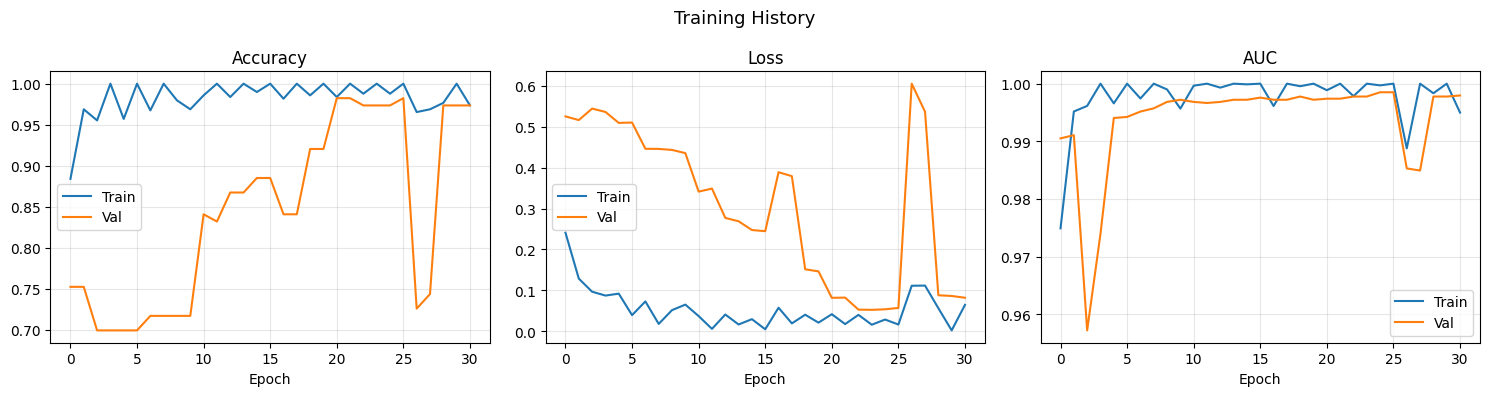

In [22]:
def plot_history(h):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric, title in zip(
        axes,
        ['accuracy', 'loss', 'auc'],
        ['Accuracy', 'Loss', 'AUC']
    ):
        ax.plot(h.history[metric],          label='Train')
        ax.plot(h.history[f'val_{metric}'], label='Val')
        ax.set_title(title);  ax.set_xlabel('Epoch')
        ax.legend();  ax.grid(alpha=0.3)
    plt.suptitle("Training History", fontsize=13)
    plt.tight_layout();  plt.show()

plot_history(history)

Test Loss     : 0.0656
Test Accuracy : 0.9735
Test AUC      : 0.9985

Classification Report:
              precision    recall  f1-score   support

       Night       1.00      0.91      0.95        34
         Day       0.96      1.00      0.98        79

    accuracy                           0.97       113
   macro avg       0.98      0.96      0.97       113
weighted avg       0.97      0.97      0.97       113



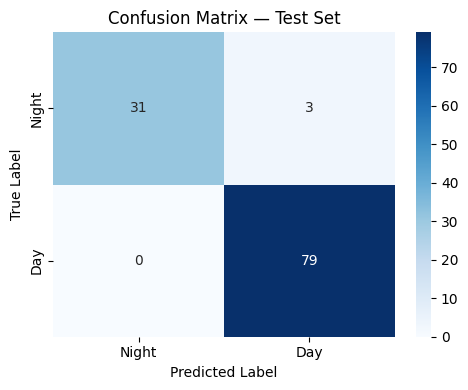

In [23]:
# Test-set metrics
loss, acc, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test AUC      : {auc:.4f}")

y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Night', 'Day']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Night', 'Day'],
            yticklabels=['Night', 'Day'])
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

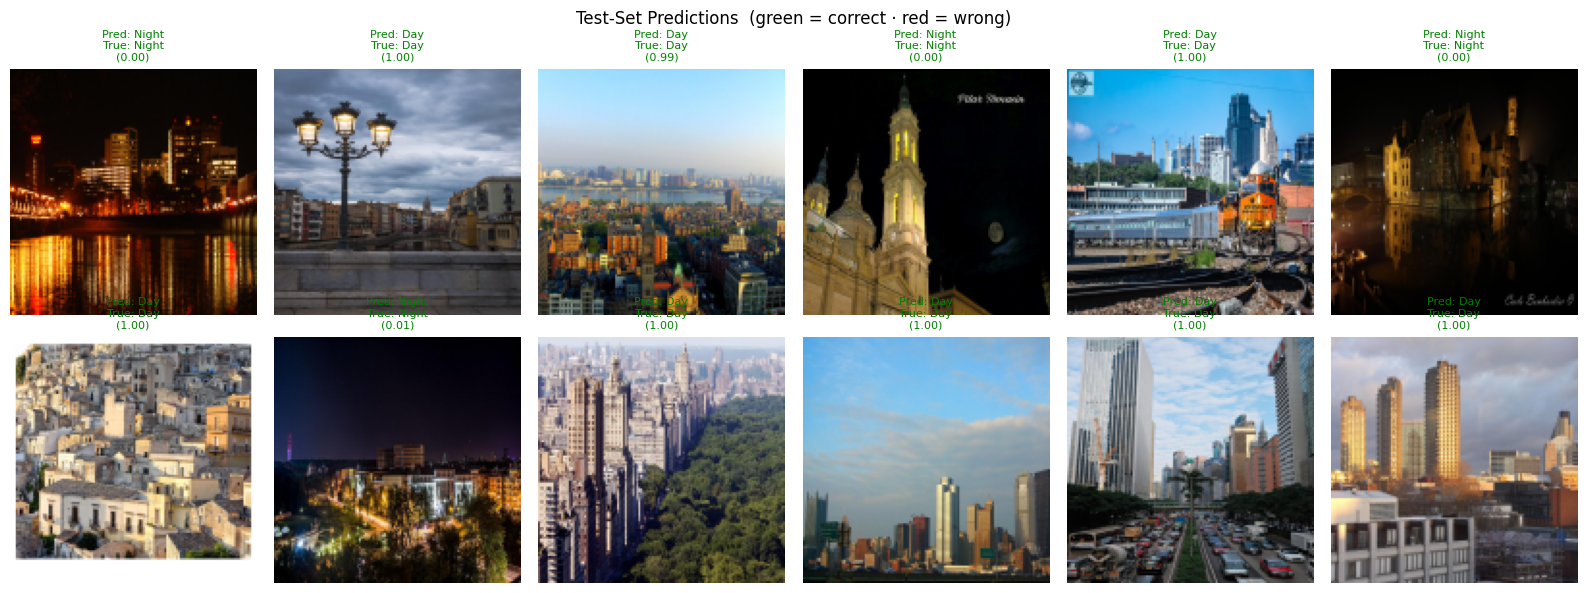

In [24]:
# Sample test-set predictions — green title = correct, red = wrong
n   = 12
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_test), n, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Test-Set Predictions  (green = correct · red = wrong)", fontsize=12)

for ax, i in zip(axes.flat, idx):
    prob  = float(model.predict(X_test[i:i+1], verbose=0)[0, 0])
    pred  = int(prob >= 0.5)
    true  = int(y_test[i])
    color = 'green' if pred == true else 'red'
    ax.imshow(X_test[i])
    ax.set_title(
        f"Pred: {CLASS_NAMES[pred]}\nTrue: {CLASS_NAMES[true]}\n({prob:.2f})",
        fontsize=8, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()